# Day 3 — Evaluation: ROUGE + RAGAS
**Goal:** Compare base Mistral-7B vs **two NyayaGPT variants** (2-epoch and 3-epoch adapters) on the eval set to pick the winning configuration.

**Metrics:**
- ROUGE-1, ROUGE-2, ROUGE-L F1 (answer quality)
- RAGAS Faithfulness + Answer Relevancy
- Inference latency per sample

**All results logged to MLflow under `nyayagpt-evaluation`.**

In [1]:
import sys, os
from pathlib import Path
from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
os.chdir(PROJECT_ROOT)

# Load Azure credentials so RAGAS can use gpt-4o-mini + text-embedding-3-small
load_dotenv(PROJECT_ROOT / '.env', override=True)

from nyaya_pipeline import config

# Keep config.* in sync with the env vars we just loaded
config.AZURE_OPENAI_KEY      = os.getenv('AZURE_OPENAI_KEY', '')
config.AZURE_OPENAI_ENDPOINT = os.getenv('AZURE_OPENAI_ENDPOINT', '')

assert config.AZURE_OPENAI_KEY, 'AZURE_OPENAI_KEY missing in .env — RAGAS will be skipped'
print(f'✓ Azure endpoint: {config.AZURE_OPENAI_ENDPOINT}')
print(f'✓ Judge deploy:   {os.getenv("AZURE_OPENAI_JUDGE_DEPLOYMENT", "gpt-4o-mini")}')
print(f'✓ Embed deploy:   {os.getenv("AZURE_OPENAI_EMBED_DEPLOYMENT", "text-embedding-3-small")}')

✓ Azure endpoint: https://gaura-mo6ykt0u-eastus2.cognitiveservices.azure.com/
✓ Judge deploy:   gpt-4o
✓ Embed deploy:   text-embedding-3-small


In [2]:
# Install RAGAS if needed
import subprocess, sys
try:
    import ragas
    print(f'✓ ragas {ragas.__version__}')
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'ragas'])
    print('ragas installed')

✓ ragas 0.4.3


In [3]:
# ── Check prerequisites ───────────────────────────────────────────────────────
from pathlib import Path

ADAPTER_2EP = PROJECT_ROOT / 'adapters-2ep'
ADAPTER_3EP = PROJECT_ROOT / 'adapters-3ep'

assert config.EVAL_JSONL.exists(), f'eval.jsonl not found: {config.EVAL_JSONL}'
assert ADAPTER_2EP.exists(), f'2-epoch adapter not found: {ADAPTER_2EP}'
assert ADAPTER_3EP.exists(), f'3-epoch adapter not found: {ADAPTER_3EP}'

n_eval = sum(1 for _ in open(config.EVAL_JSONL, encoding='utf-8'))
print(f'✓ eval.jsonl:      {n_eval} samples')
print(f'✓ adapters-2ep:    {ADAPTER_2EP}')
print(f'✓ adapters-3ep:    {ADAPTER_3EP}')

✓ eval.jsonl:      169 samples
✓ adapters-2ep:    /home/ubuntu/Fine-tuning/NyayaGPT/adapters-2ep
✓ adapters-3ep:    /home/ubuntu/Fine-tuning/NyayaGPT/adapters-3ep


## Run evaluation on both adapters
Each call evaluates `base` vs one fine-tuned adapter. We'll merge into a single comparison table after.

In [4]:
# ── Run both evaluations ─────────────────────────────────────────────────────
# Reduce n_samples for a quicker run (e.g., 10)
from nyaya_pipeline.evaluator import run_evaluation

N_SAMPLES = 50   # set to 10 for a quick smoke-test

print('━━━ Evaluating 2-epoch adapter ━━━')
results_2ep = run_evaluation(n_samples=N_SAMPLES, adapter_dir=ADAPTER_2EP)

print('\n━━━ Evaluating 3-epoch adapter ━━━')
results_3ep = run_evaluation(n_samples=N_SAMPLES, adapter_dir=ADAPTER_3EP)

# Merge into one structure: base (from 2ep run, identical in 3ep), 2ep, 3ep
results = {
    'base':          results_2ep['base'],       # identical to results_3ep['base']
    'nyayagpt-2ep':  results_2ep['finetuned'],
    'nyayagpt-3ep':  results_3ep['finetuned'],
}

print('\n=== Summary ===')
for label, metrics in results.items():
    print(f'\n{label.upper()}:')
    for k, v in metrics.items():
        print(f'  {k:<35} {v}')

━━━ Evaluating 2-epoch adapter ━━━
2026-04-20 17:53:06,458 [INFO] nyaya_pipeline.evaluator: Evaluating: base …
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/home/ubuntu/Fine-tuning/NyayaGPT/src/nyaya_pipeline/evaluator.py:37: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel


🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.3.8: Fast Mistral patching. Transformers: 4.56.2.
   \\   /|    NVIDIA GeForce RTX 5090. Num GPUs = 1. Max memory: 31.842 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
2026-04-20 17:58:17,703 [INFO] nyaya_pipeline.evaluator: RAGAS judge: Azure deployment=gpt-4o  embeddings=text-embedding-3-small


[nyaya_pipeline.evaluator|INFO]RAGAS judge: Azure deployment=gpt-4o  embeddings=text-embedding-3-small


Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

...

2026-04-20 18:42:13,254 [INFO] nyaya_pipeline.evaluator:   finetuned ROUGE-L=0.4028


[nyaya_pipeline.evaluator|INFO]  finetuned ROUGE-L=0.4028


2026-04-20 18:42:13,690 [INFO] nyaya_pipeline.evaluator: Evaluation metrics logged to MLflow


[nyaya_pipeline.evaluator|INFO]Evaluation metrics logged to MLflow



=== Summary ===

BASE:
  rouge1                              0.3848
  rouge2                              0.1454
  rougeL                              0.2382
  ragas_faithfulness                  0.5348
  ragas_answer_relevancy              0.5321
  inference_time_secs                 279.3
  ms_per_sample                       5586.1

NYAYAGPT-2EP:
  rouge1                              0.5613
  rouge2                              0.2931
  rougeL                              0.4118
  ragas_faithfulness                  0.7213
  ragas_answer_relevancy              0.4537
  inference_time_secs                 232.4
  ms_per_sample                       4648.1

NYAYAGPT-3EP:
  rouge1                              0.5683
  rouge2                              0.2994
  rougeL                              0.4028
  ragas_faithfulness                  0.6573
  ragas_answer_relevancy              0.4951
  inference_time_secs                 249.4
  ms_per_sample                       4987.4


In [5]:
# ── Comparison table: base vs 2ep vs 3ep, plus winner column ─────────────────
import pandas as pd

metrics_to_show = ['rouge1', 'rouge2', 'rougeL',
                   'ragas_faithfulness', 'ragas_answer_relevancy',
                   'ms_per_sample']

def _val(label, m):
    v = results.get(label, {}).get(m)
    if v is None: return float('nan')
    return float(v)

rows = []
for label in ['base', 'nyayagpt-2ep', 'nyayagpt-3ep']:
    row = {'Model': label}
    for m in metrics_to_show:
        row[m] = round(_val(label, m), 4)
    rows.append(row)

# Delta vs base + winner pick
delta_2ep = {m: round(_val('nyayagpt-2ep', m) - _val('base', m), 4) for m in metrics_to_show}
delta_3ep = {m: round(_val('nyayagpt-3ep', m) - _val('base', m), 4) for m in metrics_to_show}
rows.append({'Model': 'Δ 2ep vs base', **delta_2ep})
rows.append({'Model': 'Δ 3ep vs base', **delta_3ep})

# Winner between 2ep and 3ep on each metric (higher wins, except latency → lower wins)
winner = {}
for m in metrics_to_show:
    a, b = _val('nyayagpt-2ep', m), _val('nyayagpt-3ep', m)
    if m == 'ms_per_sample':
        winner[m] = '2ep' if a < b else '3ep'
    else:
        winner[m] = '2ep' if a > b else '3ep'
rows.append({'Model': 'Winner (2ep vs 3ep)', **winner})

df = pd.DataFrame(rows).set_index('Model')
print('\nFull comparison:')
df


Full comparison:


,rouge1,rouge2,rougeL,ragas_faithfulness,ragas_answer_relevancy,ms_per_sample
Model,,,,,,
base,0.3848,0.1454,0.2382,0.5348,0.5321,5586.1
nyayagpt-2ep,0.5613,0.2931,0.4118,0.7213,0.4537,4648.1
nyayagpt-3ep,0.5683,0.2994,0.4028,0.6573,0.4951,4987.4
Δ 2ep vs base,0.1765,0.1477,0.1736,0.1865,-0.0784,-938.0
Δ 3ep vs base,0.1835,0.154,0.1646,0.1225,-0.037,-598.7
Winner (2ep vs 3ep),3ep,3ep,2ep,2ep,3ep,2ep


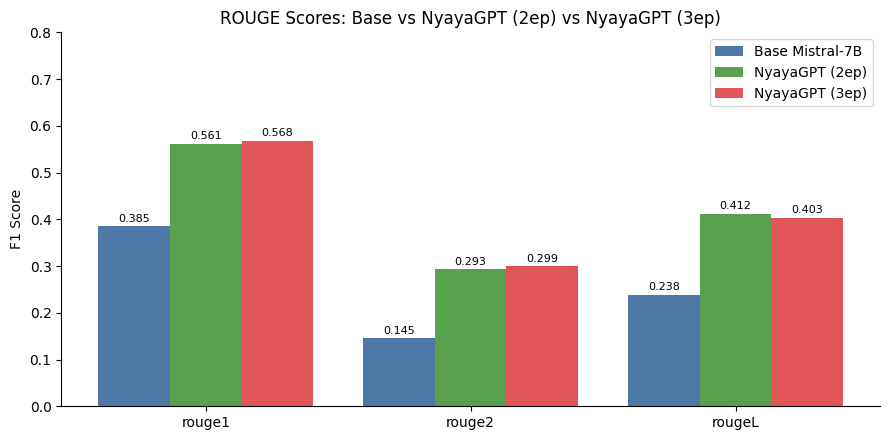

Chart saved → assets/rouge_comparison.png


In [6]:
# ── Bar chart: 3-way comparison ──────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

metrics = ['rouge1', 'rouge2', 'rougeL']
base_vals = [_val('base',         m) for m in metrics]
v2_vals   = [_val('nyayagpt-2ep', m) for m in metrics]
v3_vals   = [_val('nyayagpt-3ep', m) for m in metrics]

x = np.arange(len(metrics))
w = 0.27

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - w, base_vals, w, label='Base Mistral-7B',  color='#4e79a7')
ax.bar(x,     v2_vals,   w, label='NyayaGPT (2ep)',   color='#59a14f')
ax.bar(x + w, v3_vals,   w, label='NyayaGPT (3ep)',   color='#e15759')

# Annotate bar values
for i, vals in enumerate([base_vals, v2_vals, v3_vals]):
    for j, v in enumerate(vals):
        if not np.isnan(v):
            ax.text(x[j] + (i-1)*w, v + 0.01, f'{v:.3f}',
                    ha='center', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylabel('F1 Score')
ax.set_title('ROUGE Scores: Base vs NyayaGPT (2ep) vs NyayaGPT (3ep)')
ax.legend()
ax.set_ylim(0, max(max(v2_vals + v3_vals + base_vals) * 1.15, 0.8))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

Path('assets').mkdir(exist_ok=True)
plt.savefig('assets/rouge_comparison.png', dpi=150)
plt.show()
print('Chart saved → assets/rouge_comparison.png')

In [7]:
# ── Per-sample qualitative review: 2ep vs 3ep side-by-side ───────────────────
import json, gc, torch
from nyaya_pipeline.evaluator import _load_model_for_eval, _generate_answer
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

# Load 5 eval samples
pairs = []
with open(config.EVAL_JSONL, encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 5: break
        obj = json.loads(line)
        msgs = obj['messages']
        q   = next(m['content'] for m in msgs if m['role'] == 'user')
        ref = next(m['content'] for m in msgs if m['role'] == 'assistant')
        pairs.append((q, ref))

print('=== Qualitative Comparison (5 samples: 2ep vs 3ep) ===\n')

def _gen_all(adapter_dir, questions):
    model, tok = _load_model_for_eval(config.STUDENT_MODEL_NAME, adapter_dir)
    answers = [_generate_answer(q, model, tok) for q in questions]
    del model, tok; gc.collect(); torch.cuda.empty_cache()
    return answers

questions = [q for q, _ in pairs]
ans_2ep = _gen_all(ADAPTER_2EP, questions)
ans_3ep = _gen_all(ADAPTER_3EP, questions)

for i, ((q, ref), a2, a3) in enumerate(zip(pairs, ans_2ep, ans_3ep)):
    r2 = scorer.score(ref, a2)['rougeL'].fmeasure
    r3 = scorer.score(ref, a3)['rougeL'].fmeasure
    print(f'[{i+1}] Q: {q[:90]}…')
    print(f'     Ref:    {ref[:140]}…')
    print(f'     2ep:    {a2[:140]}…  (ROUGE-L={r2:.3f})')
    print(f'     3ep:    {a3[:140]}…  (ROUGE-L={r3:.3f})')
    print(f'     Winner: {"2ep" if r2 > r3 else ("3ep" if r3 > r2 else "tie")}\n')

=== Qualitative Comparison (5 samples: 2ep vs 3ep) ===

==((====))==  Unsloth 2026.3.8: Fast Mistral patching. Transformers: 4.56.2.
   \\   /|    NVIDIA GeForce RTX 5090. Num GPUs = 1. Max memory: 31.842 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
2026-04-20 18:45:23,046 [INFO] nyaya_pipeline.evaluator: Loaded adapter from /home/ubuntu/Fine-tuning/NyayaGPT/adapters-2ep


[nyaya_pipeline.evaluator|INFO]Loaded adapter from /home/ubuntu/Fine-tuning/NyayaGPT/adapters-2ep


==((====))==  Unsloth 2026.3.8: Fast Mistral patching. Transformers: 4.56.2.
   \\   /|    NVIDIA GeForce RTX 5090. Num GPUs = 1. Max memory: 31.842 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
2026-04-20 18:46:06,505 [INFO] nyaya_pipeline.evaluator: Loaded adapter from /home/ubuntu/Fine-tuning/NyayaGPT/adapters-3ep


[nyaya_pipeline.evaluator|INFO]Loaded adapter from /home/ubuntu/Fine-tuning/NyayaGPT/adapters-3ep


[1] Q: A client is facing a situation similar to the one described in this excerpt. Walk through …
     Ref:    **Legal analysis**

1. **Grounds for setting aside conviction** –  
   The appellant claims that the conviction and sentence are “contrary t…
     2ep:    **Legal analysis (based on the excerpt)**  

1. **Nature of the case** – The appellant is challenging a conviction and sentence in a crimina…  (ROUGE-L=0.280)
     3ep:    **Legal analysis (based solely on the excerpt)**  

1. **Nature of the dispute** – The appellant is challenging a conviction and sentence in…  (ROUGE-L=0.297)
     Winner: 3ep

[2] Q: How would a judge apply the legal rule described in this passage?

Context:
the evidence w…
     Ref:    **Answer**

A judge must first examine the entire evidence presented to determine whether the prosecution has proved each charge.  In this c…
     2ep:    **Answer**

The judge must examine the evidence presented by the prosecution to determine whether it substantiates a 

## ✅ Day 3 Complete

**Compared:** base Mistral-7B vs NyayaGPT-2ep vs NyayaGPT-3ep

**Chart saved:** `assets/rouge_comparison.png`  
**MLflow logs:** `mlruns/` (experiment: `nyayagpt-evaluation`) — two runs, one per adapter

**Winner selection rule:** higher ROUGE-L wins. Tie-break: RAGAS faithfulness → lower latency.

**Next:** Point `NY_ADAPTER_DIR` at the winning folder (or symlink `adapters/`), then run `04_quantization_benchmark.ipynb`.

## ✅ Day 3 Complete

**Chart saved:** `assets/rouge_comparison.png`  
**MLflow logs:** `mlruns/` (experiment: `nyayagpt-evaluation`)

**Next:** Run `04_quantization_benchmark.ipynb`